## **Business Problem Understanding**

An experiment was conducted on 5000 participants to study the effects of age and physical health on hearing loss, specifically the ability to hear high pitched tones. This data displays the result of the study in which participants were evaluated and scored for physical ability and then had to take an audio test (pass/no pass) which evaluated their ability to hear high frequencies. The age of the user was also noted. Is it possible to build a model that would predict someone's llikelyhood  to hear the high frequency sound based solely on their features (age and physical score)?

In [449]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as  plt
%matplotlib inline
import warnings
warnings.simplefilter('ignore')

In [450]:
df = pd.read_csv('hearing_test.csv')
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


## **Data Understanding**

- Features
    - age - Age of participent in years
    - physical_score - Score achieved during physical exam

- Label/ Targe
    - test_result - 0 if no pass, 1 if test passed

    

## Dataset Understanding

In [451]:
df.shape

(5000, 3)

In [452]:
df.columns


Index(['age', 'physical_score', 'test_result'], dtype='object')

In [453]:
df.dtypes

age               float64
physical_score    float64
test_result         int64
dtype: object

In [454]:
df.test_result.value_counts()

test_result
1    3000
0    2000
Name: count, dtype: int64

In [455]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             5000 non-null   float64
 1   physical_score  5000 non-null   float64
 2   test_result     5000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 117.3 KB


## **Exploratory Data Analysis and Visualization**

Feel free to explore the data further on your own.

In [456]:
df.describe()

,age,physical_score,test_result
count,5000.000000,5000.000000,5000.000000
mean,51.609000,32.760260,0.600000
std,11.287001,8.169802,0.489947
min,18.000000,-0.000000,0.000000
25%,43.000000,26.700000,0.000000
50%,51.000000,35.300000,1.000000
75%,60.000000,38.900000,1.000000
max,90.000000,50.000000,1.000000


<Axes: ylabel='age'>

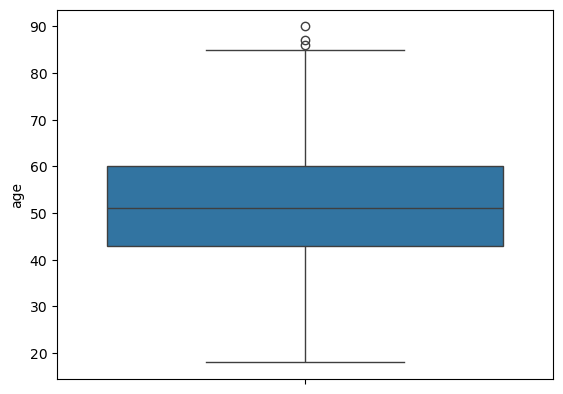

In [457]:
sns.boxplot(df['age'])

<Axes: ylabel='physical_score'>

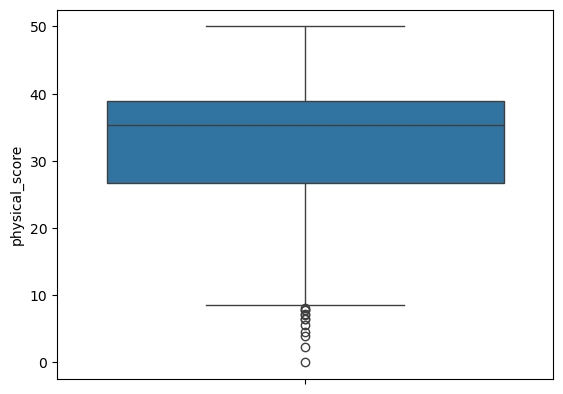

In [458]:
sns.boxplot(df.physical_score)

<Axes: ylabel='count'>

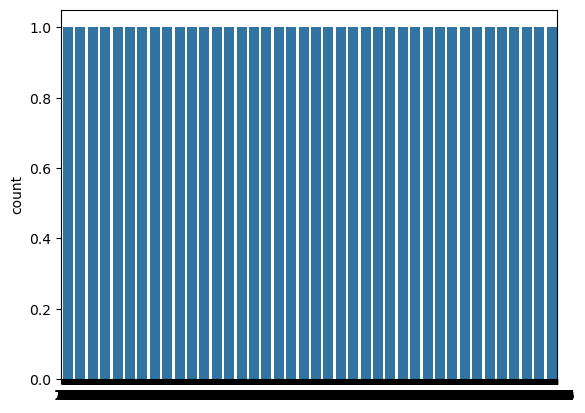

In [459]:
sns.countplot(df.test_result)

<Axes: xlabel='test_result', ylabel='count'>

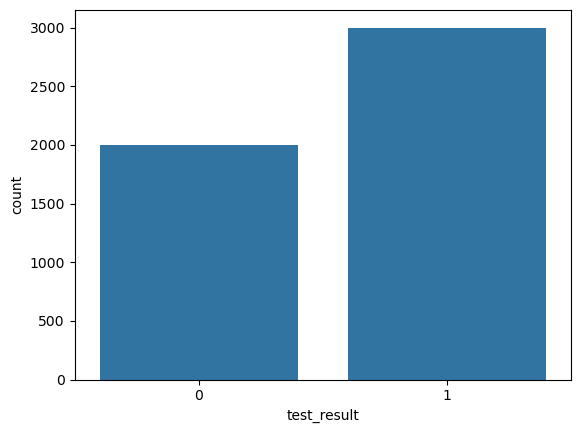

In [460]:
sns.countplot(data=df, x='test_result')

<Axes: xlabel='test_result', ylabel='age'>

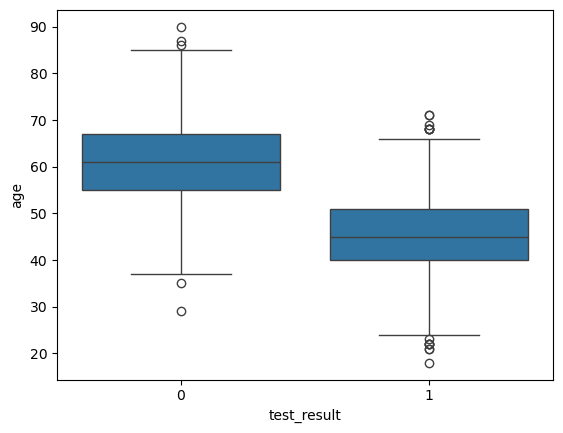

In [461]:
sns.boxplot(x='test_result', y = 'age', data = df)

<Axes: xlabel='test_result', ylabel='physical_score'>

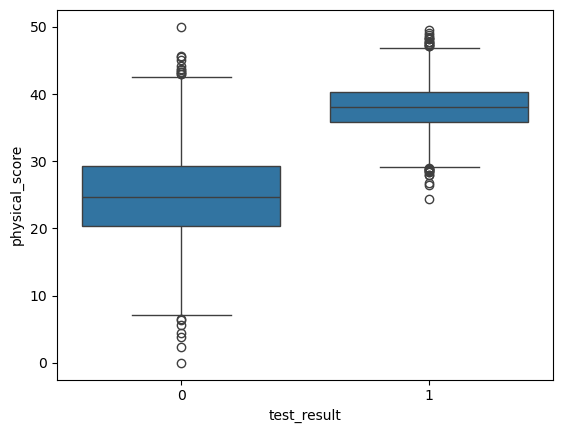

In [462]:
sns.boxplot(x='test_result', y = 'physical_score', data = df)

<Axes: xlabel='age', ylabel='physical_score'>

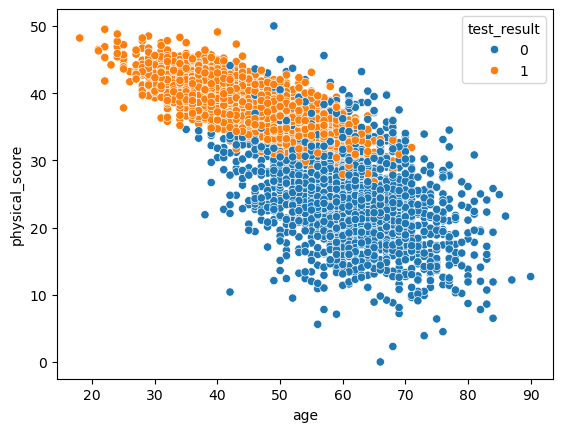

In [463]:
sns.scatterplot(x='age', y ='physical_score',data = df, hue='test_result')

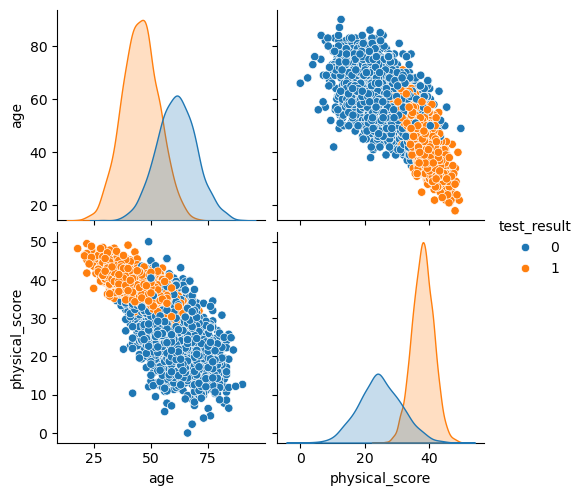

In [464]:
sns.pairplot(df, hue='test_result')

<Axes: >

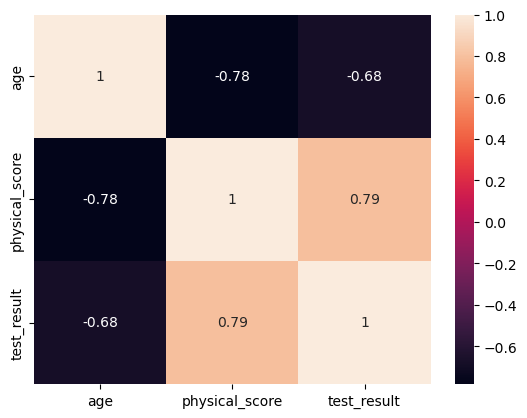

In [465]:
sns.heatmap(df.corr(), annot=True)

<Axes: xlabel='physical_score', ylabel='test_result'>

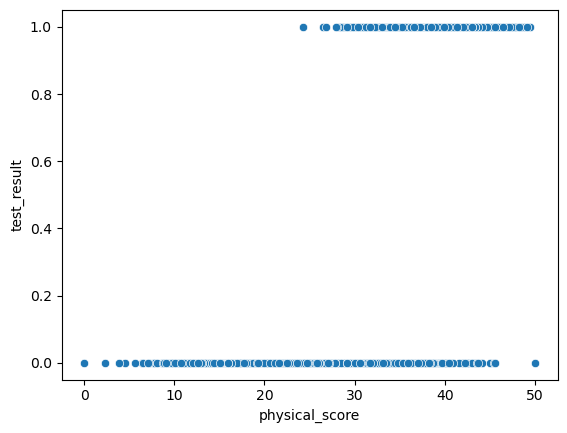

In [466]:
sns.scatterplot(x='physical_score', y ='test_result', data= df)

<Axes: xlabel='age', ylabel='test_result'>

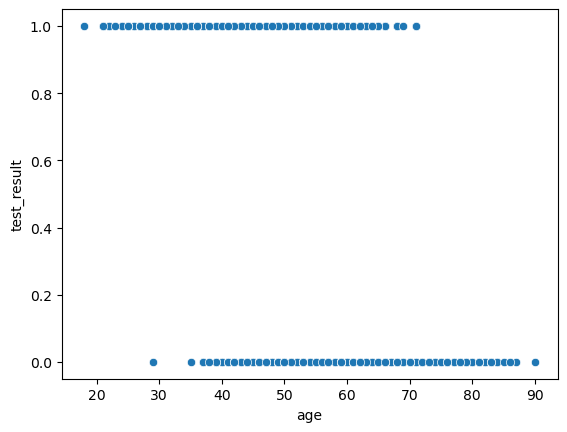

In [467]:
sns.scatterplot(x='age', y ='test_result', data= df)

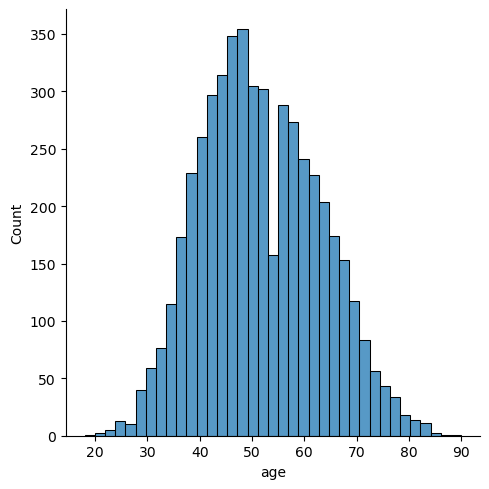

In [468]:
sns.displot(df.age)

In [469]:
df.age.skew()

np.float64(0.22094186437338537)

In [470]:
df.physical_score.skew()

np.float64(-0.7792816279520084)

In [471]:
df.isnull().sum()


age               0
physical_score    0
test_result       0
dtype: int64

### **EDA**

In [472]:
from feature_engine.outliers  import Winsorizer

win = Winsorizer(capping_method = 'iqr', variables = ['age'], tail = 'both', fold = 1.5)

df['age'] = win.fit_transform(df[['age']])

print(win.left_tail_caps_, win.right_tail_caps_)

# df.age = df.age.median()


{'age': 17.5} {'age': 85.5}


In [473]:
from feature_engine.outliers import Winsorizer 

win = Winsorizer(capping_method = 'iqr', variables=['physical_score'], tail='both', fold = 1.5)
df['physical_score'] = win.fit_transform(df[['physical_score']])
print(win.left_tail_caps_, win.right_tail_caps_)

{'physical_score': 8.399999999999999} {'physical_score': 57.20000000000001}


In [474]:
from feature_engine.outliers import Winsorizer

win= Winsorizer(capping_method='iqr',variables=['physical_score'],tail='both',fold=1.5)

df['physical_score']=win.fit_transform(df[['physical_score']])

print(win.left_tail_caps_,win.right_tail_caps_)

{'physical_score': 8.399999999999999} {'physical_score': 57.20000000000001}


#### **X & y**

In [475]:
X = df.drop('test_result', axis = 1)
y = df['test_result']

#### **Train | Test Split**

In [476]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=21,test_size=0.3)

#### **Scaling**

In [477]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_tain = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## **Modeling**

#### **Logistic Regression Model (Baseline Model or Raw Model)**

In [478]:
#import ML algorithm

from sklearn.linear_model import LogisticRegression

In [479]:
# save ML algorithm in a model

log_model = LogisticRegression()

In [480]:
# model.fit()
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [481]:
log_model.intercept_

array([-10.45472857])

In [482]:
log_model.coef_

array([[-0.07194756,  0.44664693]])

### **Prediction**

In [483]:
train_prediction = log_model.predict(X_train)
test_prediction = log_model.predict(X_test)

### **Evaluation**

In [484]:
from sklearn.metrics import accuracy_score

In [485]:
accuracy_score(y_train, train_prediction)   # Train accuaracy

0.9182857142857143

In [486]:
accuracy_score(y_test, test_prediction)  # Test accuracy

0.4033333333333333

In [487]:
from sklearn.metrics import confusion_matrix

In [488]:
confusion_matrix(y_test, test_prediction)

array([[605,   0],
       [895,   0]])

## Cross Validation Score

In [493]:
from sklearn.model_selection import cross_val_score

score = cross_val_score(log_model, X, y, cv = 5)
print(score)
score.mean()

[0.933 0.915 0.908 0.91  0.914]


np.float64(0.916)

## Classification report

In [494]:
from sklearn.metrics import classification_report 
print(classification_report(y_test, test_prediction))

              precision    recall  f1-score   support

           0       0.40      1.00      0.57       605
           1       0.00      0.00      0.00       895

    accuracy                           0.40      1500
   macro avg       0.20      0.50      0.29      1500
weighted avg       0.16      0.40      0.23      1500

